防止过拟合思路：

1.限制模型复杂度：
    1.1：控制模型的参数的数量：从模型大小上来防止模型过拟合
    1.2：控制模型的参数的大小：又叫 "权重衰退"，限制参数值选择范围来控制模型容量 

权重衰退：L2范数实现：
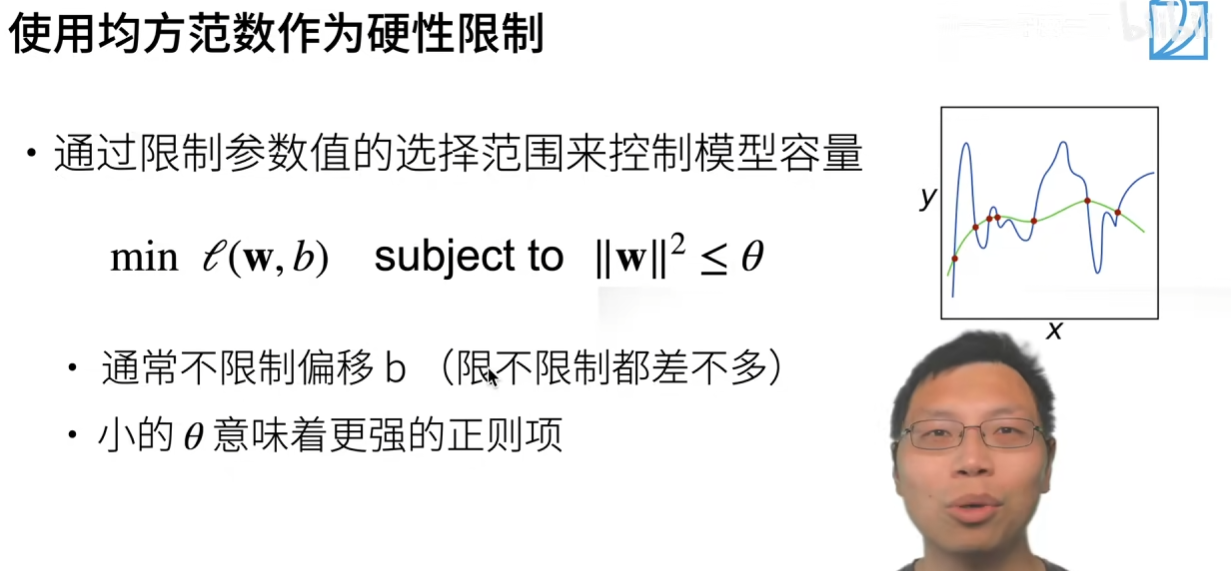
Θ越小，正则化程度越强
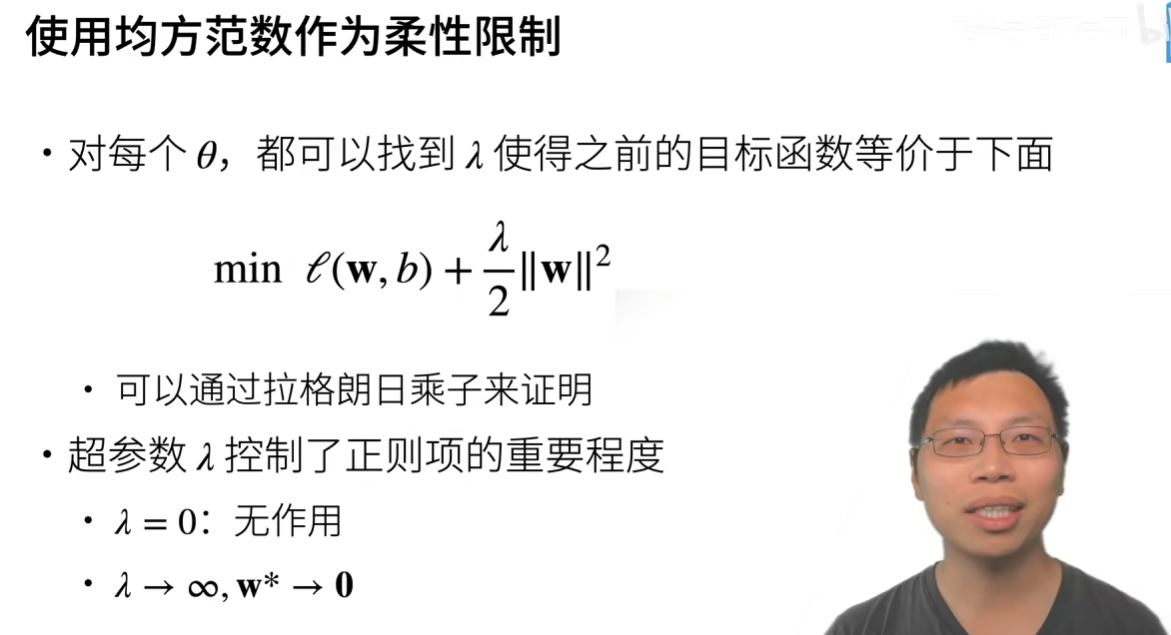 
通过拉格朗日乘子法来证明，属于是惩罚项，结构化损失函数的思想
使用lambda来控制正则化强度

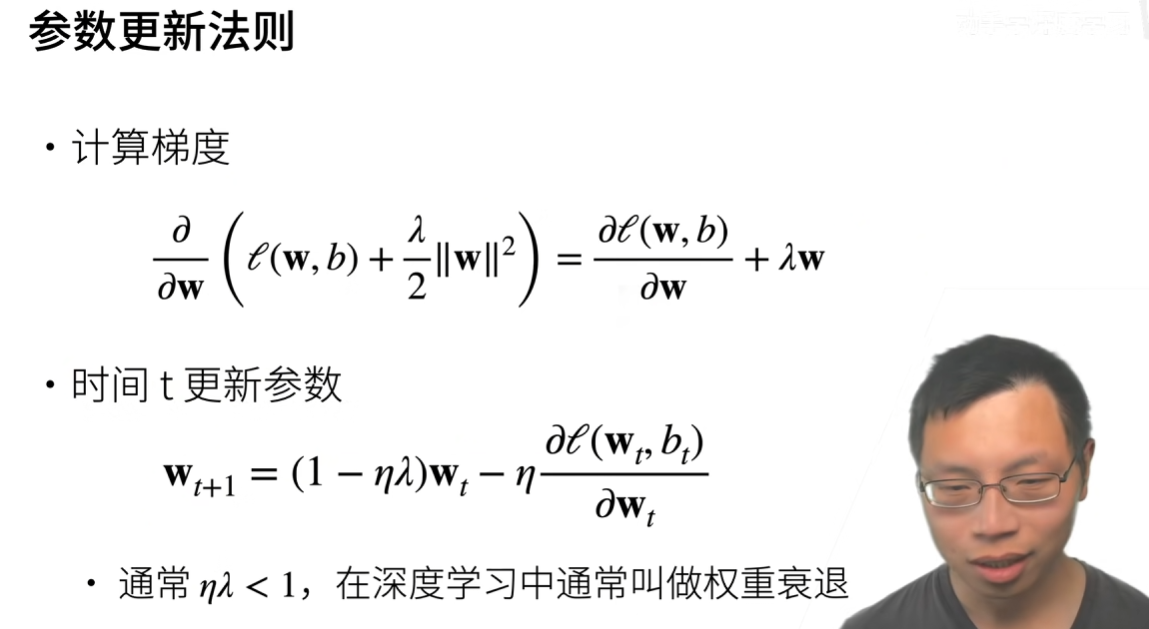
权重衰退：当模型训练至快要接近原来解位置时，整体损失函数的梯度由原来损失函数的梯度+惩罚项梯度取得，此时由于接近解，原损失函数提供的梯度比较小，此时整体梯度下降选择的方向主要由惩罚项决定，所以会朝惩罚项最小的方向来优化（lambda * w ->0），从而实现权重缩小(w ->0)。  (通常 学习率*lambda <1)

In [1]:
import numpy as np

# ========== 第 1 步:构造人工数据集 ==========
# 过拟合的前提:样本少 + 特征多,模型能"背下"训练集
np.random.seed(0)
n_train, n_test = 20, 100
num_inputs = 200          # 先作为"实验设定",用来造数据

# 真实规律:每个特征对标签只有微弱影响(0.01)
true_w = np.full((num_inputs, 1), 0.01)
true_b = 0.05

def synthetic_data(w, b, num_examples):
    """生成 y = X @ w + b + 噪声,噪声 ~ N(0, 0.01^2)"""
    X = np.random.randn(num_examples, len(w))
    y = X @ w + b + 0.01 * np.random.randn(num_examples, 1)
    return X, y

X_train, y_train = synthetic_data(true_w, true_b, n_train)
X_test, y_test = synthetic_data(true_w, true_b, n_test)

# ========== 特征数从数据读,不写死 ==========
num_inputs = X_train.shape[1]   # (20, 200) 取第 2 维 = 200
print("训练数据形状:", X_train.shape, " 测试数据形状:", X_test.shape)


训练数据形状: (20, 200)  测试数据形状: (100, 200)


In [2]:
# ========== 第 2 步:初始化参数 ==========
# 小随机数:打破对称 + 起点接近 0
W = np.random.randn(num_inputs, 1) * 0.01
b = np.zeros(1)

# ========== 第 3 步:损失函数 + L2 惩罚项(权重衰退的核心) ==========

def loss(y_hat, y):
    """均方误差(逐元素,形状和 y 相同)"""
    return (y_hat - y) ** 2

def l2_penalty(W):
    """L2 范数平方的一半:||w||^2 / 2"""
    return np.sum(W ** 2) / 2

print("初始权重的 L2 惩罚:", l2_penalty(W))

初始权重的 L2 惩罚: 0.009513558029959075


In [5]:
loss(2 * y_train,y_train)==y_train**2


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [6]:
l2_penalty(W)

0.009513558029959075

In [8]:
X_train.shape
W.shape

(200, 1)

In [22]:
def train(lambd,num_epochs=100,lr=0.003):
    #每一次更新都需要初始化：
    W=np.random.randn(num_inputs,1) * 0.01
    b=np.zeros(1)

    for epoch in range(num_epochs):
        y_hat = X_train @ W +b

        Loss= loss(y_hat,y_train) +lambd * l2_penalty(W)

        dL_W = 2 *X_train.T@(y_hat-y_train)/ n_train+lambd*W
        dL_b = 2*np.mean(y_hat-y_train)

        W -= lr * dL_W
        b -= lr * dL_b 

        if epoch %10 ==0:
            test_hat = X_test @ W+b
            print(f"epoch {epoch:3d} | 训练损失 {np.mean(loss(y_hat, y_train)):.6f} "
                  f"| 测试损失 {np.mean(loss(test_hat, y_test)):.6f} "
                  f"| ||W||^2 {np.sum(W**2):.3f}")
    return W,b
    

In [23]:
W,b = train(30)

epoch   0 | 训练损失 0.029121 | 测试损失 0.033890 | ||W||^2 0.016
epoch  10 | 训练损失 0.008714 | 测试损失 0.024847 | ||W||^2 0.002
epoch  20 | 训练损失 0.006888 | 测试损失 0.024443 | ||W||^2 0.001
epoch  30 | 训练损失 0.006564 | 测试损失 0.024762 | ||W||^2 0.000
epoch  40 | 训练损失 0.006487 | 测试损失 0.024964 | ||W||^2 0.000
epoch  50 | 训练损失 0.006468 | 测试损失 0.025058 | ||W||^2 0.000
epoch  60 | 训练损失 0.006463 | 测试损失 0.025100 | ||W||^2 0.000
epoch  70 | 训练损失 0.006461 | 测试损失 0.025119 | ||W||^2 0.000
epoch  80 | 训练损失 0.006461 | 测试损失 0.025129 | ||W||^2 0.000
epoch  90 | 训练损失 0.006461 | 测试损失 0.025135 | ||W||^2 0.000


In [27]:
W,b = train(3)

epoch   0 | 训练损失 0.026034 | 测试损失 0.043053 | ||W||^2 0.017
epoch  10 | 训练损失 0.008643 | 测试损失 0.038793 | ||W||^2 0.014
epoch  20 | 训练损失 0.003468 | 测试损失 0.036193 | ||W||^2 0.012
epoch  30 | 训练损失 0.001707 | 测试损失 0.034276 | ||W||^2 0.010
epoch  40 | 训练损失 0.001026 | 测试损失 0.032742 | ||W||^2 0.009
epoch  50 | 训练损失 0.000729 | 测试损失 0.031475 | ||W||^2 0.008
epoch  60 | 训练损失 0.000587 | 测试损失 0.030416 | ||W||^2 0.007
epoch  70 | 训练损失 0.000513 | 测试损失 0.029524 | ||W||^2 0.006
epoch  80 | 训练损失 0.000472 | 测试损失 0.028771 | ||W||^2 0.005
epoch  90 | 训练损失 0.000449 | 测试损失 0.028133 | ||W||^2 0.004


In [26]:
W,b = train(0)

epoch   0 | 训练损失 0.052646 | 测试损失 0.055476 | ||W||^2 0.020
epoch  10 | 训练损失 0.014056 | 测试损失 0.047665 | ||W||^2 0.018
epoch  20 | 训练损失 0.004388 | 测试损失 0.044419 | ||W||^2 0.018
epoch  30 | 训练损失 0.001562 | 测试损失 0.042855 | ||W||^2 0.018
epoch  40 | 训练损失 0.000616 | 测试损失 0.042018 | ||W||^2 0.019
epoch  50 | 训练损失 0.000263 | 测试损失 0.041535 | ||W||^2 0.019
epoch  60 | 训练损失 0.000119 | 测试损失 0.041240 | ||W||^2 0.019
epoch  70 | 训练损失 0.000056 | 测试损失 0.041052 | ||W||^2 0.019
epoch  80 | 训练损失 0.000027 | 测试损失 0.040927 | ||W||^2 0.019
epoch  90 | 训练损失 0.000014 | 测试损失 0.040844 | ||W||^2 0.019


epoch   0 | 训练损失 0.034646 | 测试损失 0.061629 | ||W||^2 0.019
epoch  10 | 训练损失 0.011601 | 测试损失 0.059063 | ||W||^2 0.018
epoch  20 | 训练损失 0.004187 | 测试损失 0.058044 | ||W||^2 0.018
epoch  30 | 训练损失 0.001623 | 测试损失 0.057593 | ||W||^2 0.019
epoch  40 | 训练损失 0.000673 | 测试损失 0.057373 | ||W||^2 0.019
epoch   0 | 训练损失 0.033665 | 测试损失 0.056788 | ||W||^2 0.024
epoch  10 | 训练损失 0.008662 | 测试损失 0.051306 | ||W||^2 0.022
epoch  20 | 训练损失 0.002806 | 测试损失 0.048428 | ||W||^2 0.021
epoch  30 | 训练损失 0.001131 | 测试损失 0.046515 | ||W||^2 0.020
epoch  40 | 训练损失 0.000548 | 测试损失 0.045045 | ||W||^2 0.019
epoch   0 | 训练损失 0.034700 | 测试损失 0.042046 | ||W||^2 0.020
epoch  10 | 训练损失 0.009612 | 测试损失 0.036959 | ||W||^2 0.016
epoch  20 | 训练损失 0.003493 | 测试损失 0.034086 | ||W||^2 0.014
epoch  30 | 训练损失 0.001666 | 测试损失 0.032048 | ||W||^2 0.012
epoch  40 | 训练损失 0.001005 | 测试损失 0.030462 | ||W||^2 0.010
epoch   0 | 训练损失 0.062476 | 测试损失 0.043648 | ||W||^2 0.021
epoch  10 | 训练损失 0.016313 | 测试损失 0.030165 | ||W||^2 0.011
epoch  20 | 训练

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
C:\Users\asleep\AppData\Local\Temp\ipykernel_26740\1316287162.py:33: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.tight_layout()
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy 

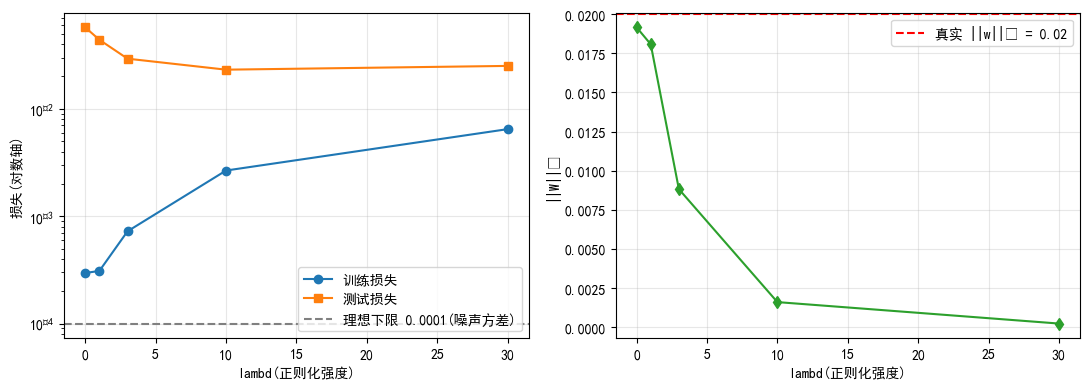

In [28]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']  # Windows 中文字体,防乱码
plt.rcParams['axes.unicode_minus'] = False

lambdas = [0, 1, 3, 10, 30]
train_losses, test_losses, w_norms = [], [], []

for l in lambdas:
    W, b = train(lambd=l, num_epochs=50)      # 如果报错说没有 num_epochs 参数,就删掉它
    train_losses.append(np.mean(loss(X_train @ W + b, y_train)))
    test_losses.append(np.mean(loss(X_test @ W + b, y_test)))
    w_norms.append(np.sum(W ** 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左图:损失 vs lambd(y 轴对数,因为损失跨度几百倍)
axes[0].semilogy(lambdas, train_losses, 'o-', label='训练损失')
axes[0].semilogy(lambdas, test_losses, 's-', label='测试损失')
axes[0].axhline(0.01 ** 2, color='gray', ls='--', label='理想下限 0.0001(噪声方差)')
axes[0].set_xlabel('lambd(正则化强度)')
axes[0].set_ylabel('损失(对数轴)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图:权重范数 vs lambd,红线是真实值
axes[1].plot(lambdas, w_norms, 'd-', color='C2')
axes[1].axhline(np.sum(true_w ** 2), color='red', ls='--', label='真实 ||w||² = 0.02')
axes[1].set_xlabel('lambd(正则化强度)')
axes[1].set_ylabel('||W||²')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
